<a href="https://colab.research.google.com/github/kapilpandey09/NLP/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import kagglehub
path = kagglehub.dataset_download("kazanova/sentiment140")

Using Colab cache for faster access to the 'sentiment140' dataset.


In [7]:
path

'/kaggle/input/sentiment140'

In [8]:
# df = pd.read_csv(path + "/training.1600000.processed.noemoticon.csv", encoding="utf-8", encoding_errors="ignore")

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [10]:
import pandas as pd

df = pd.read_csv(path +
    "/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None,
    names=[
        "sentiment",
        "id",
        "date",
        "query",
        "user",
        "text"
    ]
)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   sentiment  1600000 non-null  int64 
 1   id         1600000 non-null  int64 
 2   date       1600000 non-null  object
 3   query      1600000 non-null  object
 4   user       1600000 non-null  object
 5   text       1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [12]:
df.shape

(1600000, 6)

In [13]:
df["sentiment"].value_counts()

,count
sentiment,
0,800000
4,800000


In [14]:
df.isnull().sum()

,0
sentiment,0
id,0
date,0
query,0
user,0
text,0


In [15]:
df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [16]:
df = df[["sentiment", "text"]]

In [17]:
df["sentiment"].value_counts()

,count
sentiment,
0,800000
4,800000


In [18]:
df["sentiment"].nunique()

2

In [19]:
df

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."
...,...,...
1599995,4,Just woke up. Having no school is the best fee...
1599996,4,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,Happy 38th Birthday to my boo of alll time!!! ...


In [20]:
df["sentiment"] = df["sentiment"].replace({4:1})

In [21]:
df

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."
...,...,...
1599995,1,Just woke up. Having no school is the best fee...
1599996,1,TheWDB.com - Very cool to hear old Walt interv...
1599997,1,Are you ready for your MoJo Makeover? Ask me f...
1599998,1,Happy 38th Birthday to my boo of alll time!!! ...


<Axes: xlabel='sentiment'>

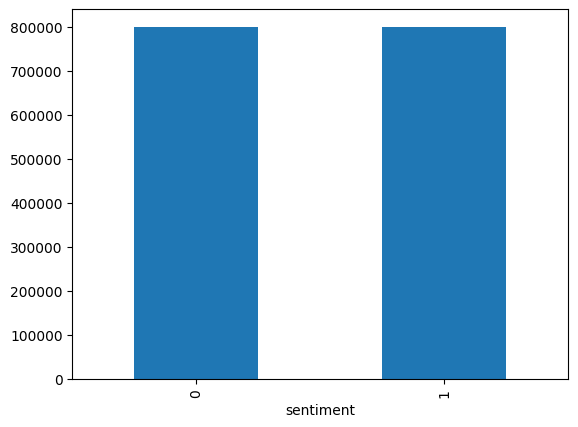

In [22]:
df["sentiment"].value_counts().plot(kind="bar")

In [23]:
df.duplicated().sum()

np.int64(16309)

In [24]:
df["text"].duplicated().sum()

np.int64(18534)

In [25]:
# df["char_count"] = df["text"].str.len()
# df["char_count"].describe()

In [26]:
# df["word_count"] = df["text"].str.split().str.len()
# df["word_count"].describe()

In [27]:
df[df["sentiment"]==1]["text"].sample(5)

,text
811873,@welnis hey back
1218958,"Ð¢Ð¾Ð»ÑÐºÐ¾ ÑÑÐ¾, ÑÑ?Ð´Ð¾Ð¼ Ñ?Ð¾ Ð¼Ð½Ð¾Ð¹ ..."
1380170,Going go-kart racing tomorrow. Should be a bl...
812153,@bearheadedgirl I don't want to get greedy.
1041138,@SuP3rK Hey!!!!! I'm out par-taying!!!


In [28]:
df[df["sentiment"]==0]["text"].sample(5)

,text
549824,@patmaddox My bad.
435701,The thunder this moring was really scary! I hi...
475351,"The reality is sinking in, and it is sooo sad"
647777,On the road! Its early and my mom won't let me...
377373,is still wearing her pjs though its late in th...


In [29]:
conflict = (
    df.groupby("text")["sentiment"]
      .nunique()
      .reset_index()
)

conflict[conflict["sentiment"] > 1]

,text,sentiment
1045,British weather is back i see! Oh well Birtne...,2
1656,I love you,2
2450,Raining tomorrow afternoon but its going to b...,2
2617,That is all.,2
2709,Uhm.. science! -.- Verrrry boring and LONG G...,2
...,...,...
1576926,yay finished lord of the flies study questions...,2
1577083,yay i dont have glandular fever! but i do hav...,2
1577269,yay no work todayyy but working for the rest...,2
1579059,"yesterday was AMAZING ! See Nere today again,...",2


In [30]:
conflict

,text,sentiment
0,exh...,1
1,I miss he...,1
2,is so sad for my APL frie...,1
3,I missed the New Moon trail...,1
4,I HAVE NOOOOOOOOOO FRIENDS ON T...,1
...,...,...
1581461,ï¿½ï¿½We are ready for the new generation!!......,1
1581462,"ï¿½ï¿½h remember the titans at english class, ...",1
1581463,ï¿½ï¿½h. iï¿½m gonna go in the &quot;big&quot;...,1
1581464,ï¿½ï¿½ï¿½ It's my Birthday !!!!!!!!!!!!!!,1


In [31]:
# df = df[~df["text"].isin(conflict_texts)]

In [32]:
df = (
    df.groupby("text")["sentiment"]
      .agg(lambda x: x.mode()[0])
      .reset_index()
)

In [33]:
conflict = (
    df.groupby("text")["sentiment"]
      .nunique()
)

print("Conflicting texts:", (conflict > 1).sum())

Conflicting texts: 0


In [34]:
"Duplicate rows:", df.duplicated().sum()

('Duplicate rows:', np.int64(0))

In [35]:
print((df["text"].str.strip() == "").sum())

0


In [36]:
print(df["text"].nunique())

1581466


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581466 entries, 0 to 1581465
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   text       1581466 non-null  object
 1   sentiment  1581466 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 24.1+ MB


<Axes: xlabel='sentiment'>

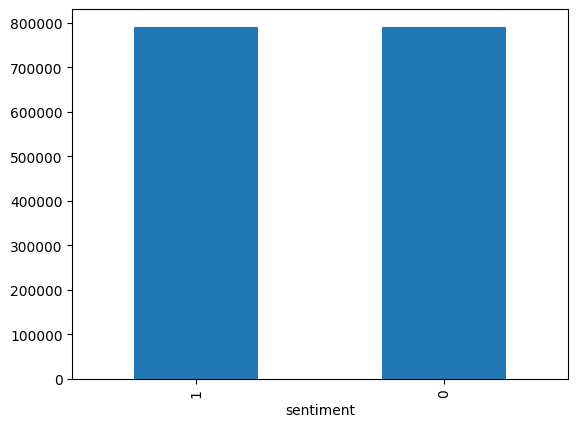

In [38]:
df["sentiment"].value_counts().plot(kind="bar")


In [39]:
df.isnull().sum()

,0
text,0
sentiment,0


In [40]:
# negative_words = " ".join(
#     df[df["sentiment"]==0]["text"]
# )

In [41]:
# positive_words = " ".join(
#     df[df["sentiment"]==1]["text"]
# )

In [42]:
df["text"].str.contains("http").sum()

np.int64(68847)

In [43]:
df["text"].str.contains("@").sum()

np.int64(743711)

In [44]:
df["text"].str.contains("#").sum()

np.int64(36462)

In [45]:
df["text"].sample(20)

,text
1511780,so... it seems my favorite t20 teams are jinxe...
1166828,They will have afternoon tea with fans soon.. ...
657647,@spokesdog I am lost. Please help me find a go...
801713,Down 14lbs... So proud of me
639089,@sensonize hmmm... thats better. Cuz following...
1435877,last Friday at my school! graduating on to gra...
1520419,summer is over! 12 more months!!
123505,@HareemKhan lol if you say so. I won't say an...
523139,@lisakeksi c'mon i know u like it ur waffel a...
909720,I hate the whole city of Brandon


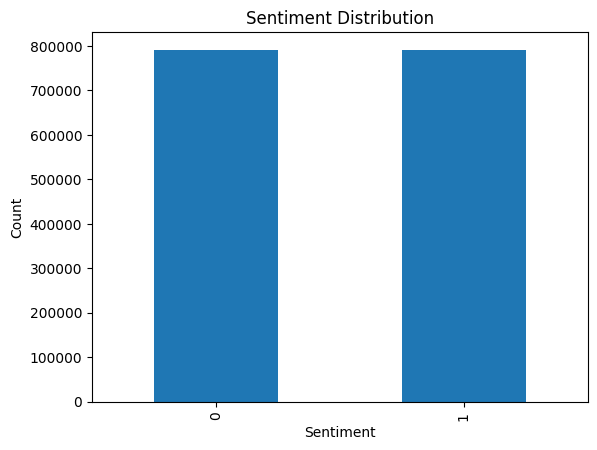

In [46]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [47]:
(df["text"].str.strip() == "").sum()

np.int64(0)

In [48]:
print(df.shape)
print(df["sentiment"].value_counts())
print(df["text"].nunique())

(1581466, 2)
sentiment
1    791396
0    790070
Name: count, dtype: int64
1581466


In [49]:
df["length"] = df["text"].str.split().str.len()

df["length"].describe(percentiles=[0.5,0.9,0.95,0.99])

,length
count,1.581466e+06
mean,1.324630e+01
std,6.924885e+00
min,1.000000e+00
50%,1.200000e+01
90%,2.300000e+01
95%,2.500000e+01
99%,2.800000e+01
max,6.400000e+01


In [50]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(df["text"])

print(len(tokenizer.word_index))

690960


In [51]:
df["clean_text"] = df["text"]

In [52]:
import re

def clean_text(text):

    # lowercase
    text = text.lower()

    # URLs -> placeholder
    text = re.sub(r'http\S+|www\S+', ' url ', text)

    # User mentions -> placeholder
    text = re.sub(r'@\w+', ' user ', text)

    # hashtags symbol remove, word preserve
    text = re.sub(r'#', '', text)

    # Positive emoticons
    text = re.sub(r'(:\)|:-\)|:d|=d|=\))', ' emo_pos ', text)

    # Negative emoticons
    text = re.sub(r'(:\(|:-\(|=\()', ' emo_neg ', text)

    # Common contractions
    text = re.sub(r"don't", "do not", text)
    text = re.sub(r"can't", "can not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)

    # Repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Keep only letters and underscore
    text = re.sub(r'[^a-zA-Z_\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [53]:
df["clean_text"] = df["text"].apply(clean_text)

In [54]:
df[["text", "clean_text"]].head()

,text,clean_text
0,exh...,exhausted
1,I miss he...,i miss her so much already
2,is so sad for my APL frie...,is so sad for my apl friend
3,I missed the New Moon trail...,i missed the new moon trailer
4,I HAVE NOOOOOOOOOO FRIENDS ON T...,i have noo friends on twitter it makes me sad ...


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

In [56]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 50000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [57]:
# X_train_seq

In [58]:
# tokenizer.word_index

In [64]:
tweet_lengths = df["clean_text"].str.split().apply(len)

print(tweet_lengths.describe())

count    1.581466e+06
mean     1.358933e+01
std      7.156329e+00
min      1.000000e+00
25%      8.000000e+00
50%      1.300000e+01
75%      1.900000e+01
max      5.300000e+01
Name: clean_text, dtype: float64


In [65]:
print(tweet_lengths.quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

0.50    13.0
0.75    19.0
0.90    24.0
0.95    26.0
0.99    29.0
Name: clean_text, dtype: float64


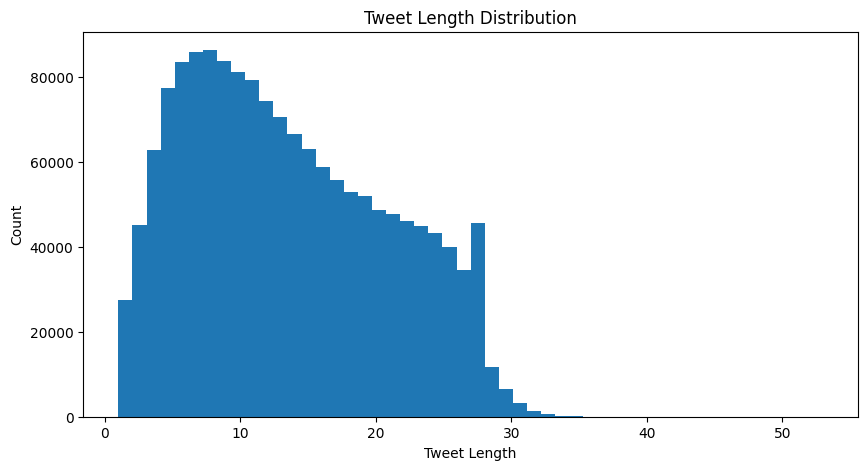

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    tweet_lengths,
    bins=50
)

plt.xlabel("Tweet Length")
plt.ylabel("Count")
plt.title("Tweet Length Distribution")

plt.show()

In [67]:
MAX_LEN = 30

truncated = (tweet_lengths > MAX_LEN).sum()

percentage = (
    truncated / len(tweet_lengths)
) * 100

print(f"Truncated Tweets: {truncated}")
print(f"Percentage: {percentage:.2f}%")

Truncated Tweets: 5390
Percentage: 0.34%


In [59]:

MAX_LEN = 30

from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"

)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"

)

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.regularizers import l2


model = Sequential([
    Input(shape=(30,)),

    Embedding(
        input_dim=50000,
        output_dim=128,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(128, dropout=0.2)
    ),

    Dropout(0.3),

    Dense(
    64,
    activation="relu",

    kernel_regularizer=l2(1e-4)
),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 30, 128)        │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,679,681 (25.48 MB)

 Trainable params: 6,679,681 (25.48 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(1265172, 30)
(316294, 30)


In [79]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [80]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=512,
    callbacks=[early_stop]
)

Epoch 1/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 46s 19ms/step - accuracy: 0.8073 - loss: 0.4207 - val_accuracy: 0.8246 - val_loss: 0.3879
Epoch 2/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.8361 - loss: 0.3673 - val_accuracy: 0.8276 - val_loss: 0.3813
Epoch 3/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.8507 - loss: 0.3392 - val_accuracy: 0.8271 - val_loss: 0.3901
Epoch 4/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.8647 - loss: 0.3112 - val_accuracy: 0.8269 - val_loss: 0.4068


In [81]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

9885/9885 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - accuracy: 0.8274 - loss: 0.3832
Test Loss : 0.3832254111766815
Test Accuracy : 0.8273694515228271


In [82]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

9885/9885 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step


In [86]:
len(y_pred)

316294

In [83]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83    158014
           1       0.83      0.83      0.83    158280

    accuracy                           0.83    316294
   macro avg       0.83      0.83      0.83    316294
weighted avg       0.83      0.83      0.83    316294



In [84]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[130293  27721]
 [ 26881 131399]]


In [87]:
!wget https://nlp.stanford.edu/data/glove.twitter.27B.zip
!unzip glove.twitter.27B.zip

--2026-06-17 08:32:56--  https://nlp.stanford.edu/data/glove.twitter.27B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.twitter.27B.zip [following]
--2026-06-17 08:32:56--  https://downloads.cs.stanford.edu/nlp/data/glove.twitter.27B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1520408563 (1.4G) [application/zip]
Saving to: ‘glove.twitter.27B.zip’

glove.twitter.27B.z 100%[===================>]   1.42G  5.00MB/s    in 4m 44s  

2026-06-17 08:37:40 (5.11 MB/s) - ‘glove.twitter.27B.zip’ saved [1520408563/1520408563]

Archive:  glove.twitter.27B.zip
  inflating: glove.twitter.27

In [88]:
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

In [89]:
embeddings_index = {}

with open(
    "glove.twitter.27B.100d.txt",
    encoding="utf8"
) as f:

    for line in f:
        values = line.split()

        word = values[0]

        coefs = np.asarray(
            values[1:],
            dtype="float32"
        )

        embeddings_index[word] = coefs

print("Loaded vectors:", len(embeddings_index))

Loaded vectors: 1193514


In [90]:
vocab_size = 50000
embedding_dim = 100

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim)
)

for word, idx in tokenizer.word_index.items():

    if idx >= vocab_size:
        continue

    vector = embeddings_index.get(word)

    if vector is not None:
        embedding_matrix[idx] = vector

print("Embedding matrix shape:")
print(embedding_matrix.shape)

Embedding matrix shape:
(50000, 100)


In [91]:
model = Sequential([

    Input(shape=(30,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(
            128,
            dropout=0.2
        )
    ),

    Dropout(0.3),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [92]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 30, 100)        │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251,009 (20.03 MB)

 Trainable params: 251,009 (980.50 KB)

 Non-trainable params: 5,000,000 (19.07 MB)

In [93]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=512,
    callbacks=[early_stop]
)

Epoch 1/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - accuracy: 0.7835 - loss: 0.4594 - val_accuracy: 0.8130 - val_loss: 0.4079
Epoch 2/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.8102 - loss: 0.4140 - val_accuracy: 0.8223 - val_loss: 0.3921
Epoch 3/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.8189 - loss: 0.3981 - val_accuracy: 0.8286 - val_loss: 0.3818
Epoch 4/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.8245 - loss: 0.3880 - val_accuracy: 0.8321 - val_loss: 0.3745
Epoch 5/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.8288 - loss: 0.3804 - val_accuracy: 0.8328 - val_loss: 0.3717
Epoch 6/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - accuracy: 0.8320 - loss: 0.3746 - val_accuracy: 0.8355 - val_loss: 0.3660
Epoch 7/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.8346 - loss: 0.3700 - val_accuracy: 0.8353 - val_loss: 0.3659
Epoch 8/10
2224/2224 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.8368 -

In [94]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

9885/9885 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - accuracy: 0.8386 - loss: 0.3622
Test Loss : 0.3622308671474457
Test Accuracy : 0.8386311531066895


In [95]:
y_pred_prob = model.predict(X_test_pad)

y_pred = (
    y_pred_prob > 0.5
).astype(int)

9885/9885 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step


In [96]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.85      0.84    158014
           1       0.85      0.83      0.84    158280

    accuracy                           0.84    316294
   macro avg       0.84      0.84      0.84    316294
weighted avg       0.84      0.84      0.84    316294



In [97]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[134361  23653]
 [ 27387 130893]]


# Base line models

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X = tfidf.fit_transform(df["clean_text"])
y = df["sentiment"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

In [ ]:
tweet = "I love this phone. Camera is amazing."

tweet = clean_text(tweet)

tweet_vector = tfidf.transform([tweet])

prediction = model.predict(tweet_vector)

print(prediction)

[1]


In [ ]:

# tfidf.vocabulary_

In [ ]:
len(tfidf.vocabulary_)

10000

In [ ]:
import pandas as pd

feature_names = tfidf.get_feature_names_out()

coefficients = model.coef_[0]

top_positive = pd.DataFrame({
    "word": feature_names,
    "weight": coefficients
}).sort_values(
    by="weight",
    ascending=False
)

top_positive.head(20)

,word,weight
9608,welcome,4.425911
7965,smiling,4.362246
8745,thank,4.317829
8750,thanks,4.230512
1809,congratulations,4.044279
877,blessed,3.935555
7961,smile,3.774957
3566,glad,3.675584
6573,pleasure,3.585660
9427,vip,3.521278


In [ ]:
top_negative = pd.DataFrame({
    "word": feature_names,
    "weight": coefficients
}).sort_values(
    by="weight",
    ascending=True
)

top_negative.head(20)

,word,weight
7431,sad,-10.371704
1172,bummed,-6.996028
3762,gutted,-6.610203
7439,sadly,-6.296437
5540,miss,-6.129826
6605,poor,-6.076659
7398,ruined,-5.770673
5544,missing,-5.747301
2389,disappointed,-5.739631
8405,sucks,-5.656383


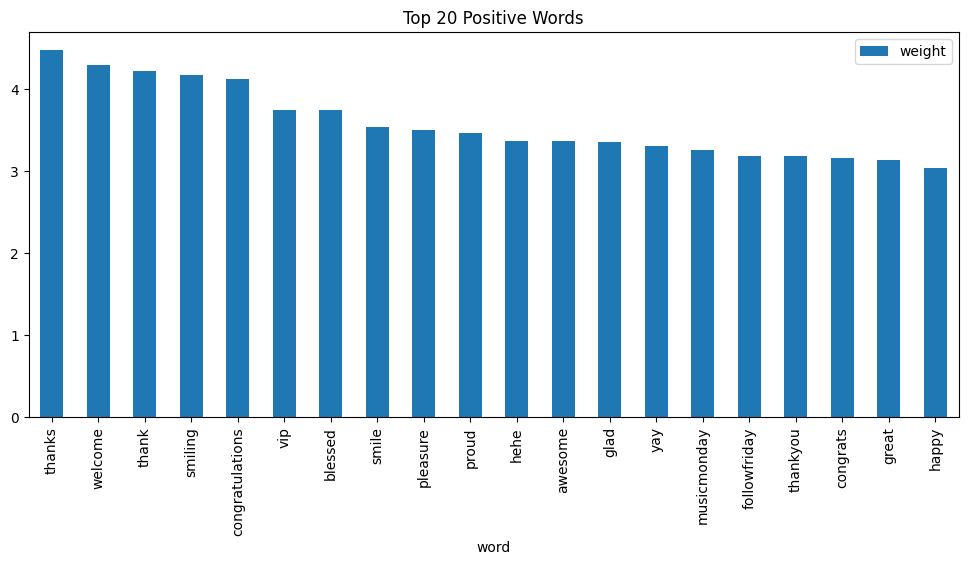

In [ ]:
top_positive.head(20).plot(
    x="word",
    y="weight",
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 20 Positive Words")
plt.show()

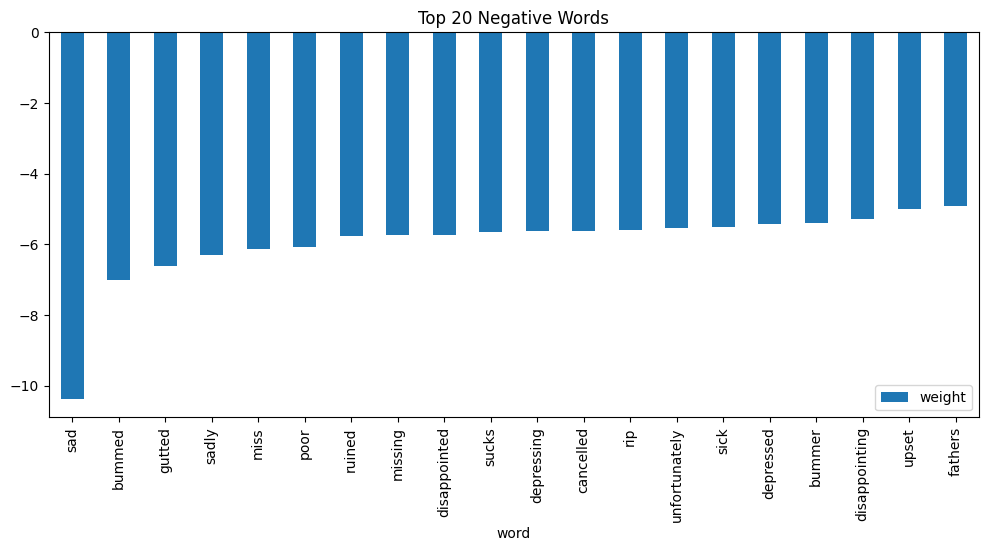

In [ ]:
top_negative.head(20).plot(
    x="word",
    y="weight",
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 20 Negative Words")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.8517978204973874


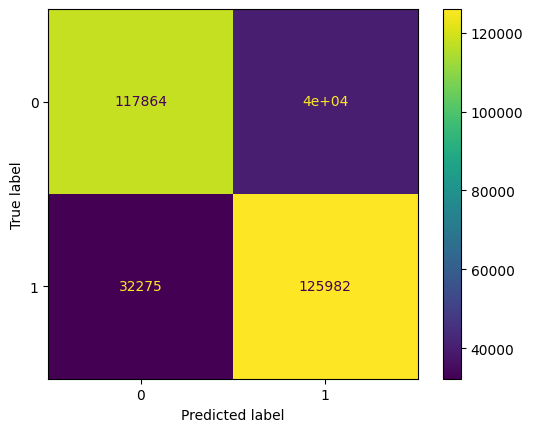

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [ ]:
tweet = "This phone is amazing"

tweet = clean_text(tweet)

vector = tfidf.transform([tweet])

print(model.predict(vector))
print(model.predict_proba(vector))

[1]
[[0.19848425 0.80151575]]


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

# Features and Target
X = df["clean_text"]
y = df["sentiment"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    ),

    "Linear SVC": LinearSVC(),

    # "Naive Bayes": MultinomialNB(),

    # "SGD Classifier": SGDClassifier(
    #     random_state=42
    # )


}

results = []

for name, model in models.items():

    print(f"\n{'='*60}")
    print(f"Training : {name}")
    print(f"{'='*60}")

    pipeline = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 3),
                min_df=5,
                max_df=0.95,
                sublinear_tf=True,
                stop_words=None
            )
        ),
        ("model", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2)
    })

    print(f"\nAccuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred))

# Comparison Table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*60)
print("FINAL COMPARISON")
print("="*60)

print(results_df)


Training : Logistic Regression

Accuracy: 0.8181

              precision    recall  f1-score   support

           0       0.82      0.81      0.82    158037
           1       0.81      0.83      0.82    158257

    accuracy                           0.82    316294
   macro avg       0.82      0.82      0.82    316294
weighted avg       0.82      0.82      0.82    316294


Training : Linear SVC

Accuracy: 0.8175

              precision    recall  f1-score   support

           0       0.83      0.80      0.81    158037
           1       0.81      0.83      0.82    158257

    accuracy                           0.82    316294
   macro avg       0.82      0.82      0.82    316294
weighted avg       0.82      0.82      0.82    316294



FINAL COMPARISON
                 Model  Accuracy
0  Logistic Regression     81.81
1           Linear SVC     81.75


In [ ]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=50000,
            ngram_range=(1,3)
        )),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    print(
        f"{name}: "
        f"{scores.mean():.4f} "
        f"(+/- {scores.std():.4f})"
    )

Logistic Regression: 0.8172 (+/- 0.0011)
Linear SVC: 0.8150 (+/- 0.0008)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

c_values = [0.1, 0.5, 1, 2, 5, 10]

results = []

for c in c_values:

    pipe = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=100000,
                ngram_range=(1,2),
                min_df=5,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "model",
            LogisticRegression(
                C=c,
                max_iter=1000,
                n_jobs=-1
            )
        )
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append((c, acc))

    print(f"C={c}  Accuracy={acc:.4f}")

print("\nFinal Results")
for c, acc in results:
    print(f"C={c} -> {acc:.4f}")

C=0.1  Accuracy=0.8089
C=0.5  Accuracy=0.8197
C=1  Accuracy=0.8217
C=2  Accuracy=0.8219
C=5  Accuracy=0.8203
C=10  Accuracy=0.8203

Final Results
C=0.1 -> 0.8089
C=0.5 -> 0.8197
C=1 -> 0.8217
C=2 -> 0.8219
C=5 -> 0.8203
C=10 -> 0.8203


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

configs = [
    ((1,1), 50000),
    ((1,2), 50000),
    ((1,2), 100000),
    ((1,3), 100000)
]

for ngram, features in configs:

    pipe = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=features,
                ngram_range=ngram,
                min_df=5,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "model",
            LogisticRegression(
                C=2,
                max_iter=1000,
                n_jobs=-1
            )
        )
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(
        f"Ngram={ngram}, "
        f"Features={features}, "
        f"Accuracy={acc:.4f}"
    )

Ngram=(1, 1), Features=50000, Accuracy=0.7997
Ngram=(1, 2), Features=50000, Accuracy=0.8183
Ngram=(1, 2), Features=100000, Accuracy=0.8219
Ngram=(1, 3), Features=100000, Accuracy=0.8217


In [ ]:
from sklearn.linear_model import SGDClassifier

pipe = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=100000,
            ngram_range=(1,2),
            min_df=5,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "model",
        SGDClassifier(
            loss="log_loss",
            alpha=1e-5,
            random_state=42
        )
    )
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print(
    "SGD Accuracy:",
    accuracy_score(y_test, y_pred)
)

SGD Accuracy: 0.807217335769885


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

sgd_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=100000,
            ngram_range=(1,2),
            min_df=5,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "model",
        SGDClassifier(
            loss="log_loss",
            alpha=1e-5,
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        )
    )
])

print("Training SGDClassifier...")

sgd_pipeline.fit(X_train, y_train)

y_pred = sgd_pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {acc:.4f}\n")

print(classification_report(y_test, y_pred))

Training SGDClassifier...

Accuracy: 0.8072

              precision    recall  f1-score   support

           0       0.81      0.80      0.81    158037
           1       0.80      0.81      0.81    158257

    accuracy                           0.81    316294
   macro avg       0.81      0.81      0.81    316294
weighted avg       0.81      0.81      0.81    316294



In [ ]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd

from gensim.models import FastText

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:


X_text = df["clean_text"].astype(str)

y = df["sentiment"]

sentences = X_text.apply(lambda x: x.split())

# =========================
# Train FastText
# =========================

print("Training FastText...")

ft_model = FastText(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,          # Skip-Gram
    epochs=10
)



print("FastText Training Complete")

# =========================
# Sentence Embedding Function
# =========================

def get_sentence_embedding(tokens):

    vectors = []

    for word in tokens:

        if word in ft_model.wv:
            vectors.append(ft_model.wv[word])

    if len(vectors) == 0:
        return np.zeros(ft_model.vector_size)

    return np.mean(vectors, axis=0)


# =========================
# Create Feature Matrix
# =========================

print("Creating Embeddings...")

X = np.array(
    [get_sentence_embedding(tokens)
     for tokens in sentences]
)

print("Embedding Shape:", X.shape)



# =========================
# Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# Logistic Regression
# =========================

print("Training Logistic Regression...")

model = LogisticRegression(
    C=2,
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Training Complete")


# =========================
# Prediction
# =========================

y_pred = model.predict(X_test)


# =========================
# Evaluation
# =========================

acc = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(acc, 4))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)


Training FastText...
FastText Training Complete
Creating Embeddings...
Embedding Shape: (1581466, 100)
Training Logistic Regression...
Training Complete

Accuracy: 0.7403

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.74      0.74    158037
           1       0.74      0.74      0.74    158257

    accuracy                           0.74    316294
   macro avg       0.74      0.74      0.74    316294
weighted avg       0.74      0.74      0.74    316294

